In [1]:
import os

# set your default path here
os.chdir("/Users/aditya/Downloads/Medisyn_Labs_case_study")

# confirm
print("Current Working Directory:", os.getcwd())


Current Working Directory: /Users/aditya/Downloads/Medisyn_Labs_case_study


Train shape: (3107, 9)
Test shape: (1036, 9)

Preview of train data:
   customer_id     medicine_name  rating     effectiveness  \
0         2202         enalapril       4  Highly Effective   
1         3117  ortho-tri-cyclen       1  Highly Effective   
2         1146           ponstel      10  Highly Effective   

   side_effects_rating                               condition  \
0    Mild Side Effects  management of congestive heart failure   
1  Severe Side Effects                        birth prevention   
2      No Side Effects                        menstrual cramps   

                                     review_benefits  \
0  slowed the progression of left ventricular dys...   
1  Although this type of birth control has more c...   
2  I was used to having cramps so badly that they...   

                                 review_side_effects  \
0  cough, hypotension , proteinuria, impotence , ...   
1  Heavy Cycle, Cramps, Hot Flashes, Fatigue, Lon...   
2         Heavier bleedi

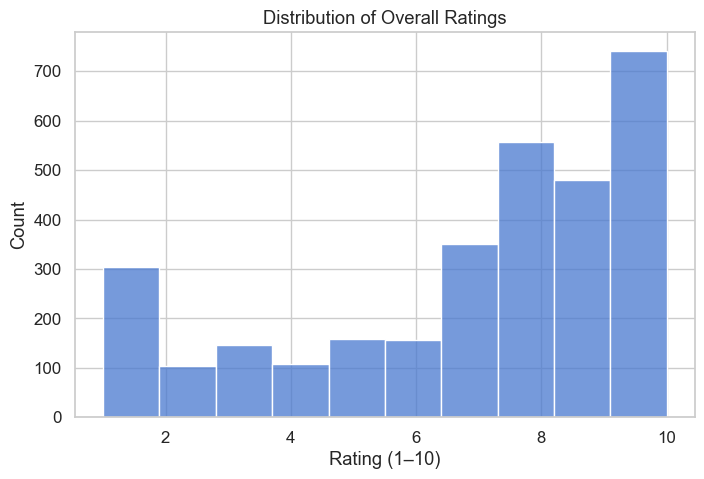

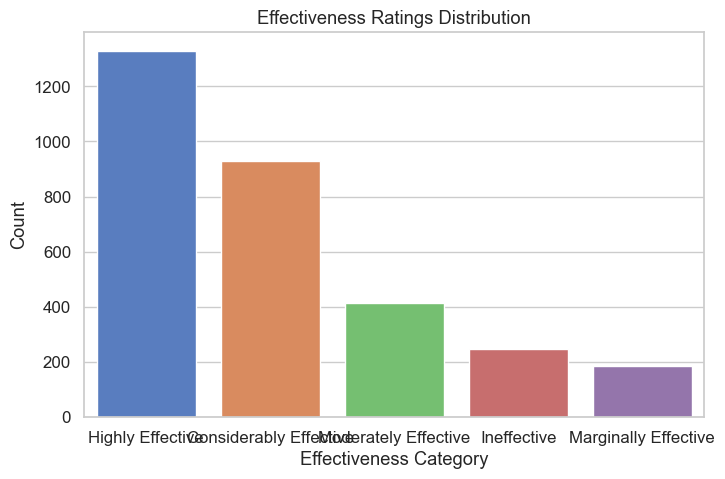

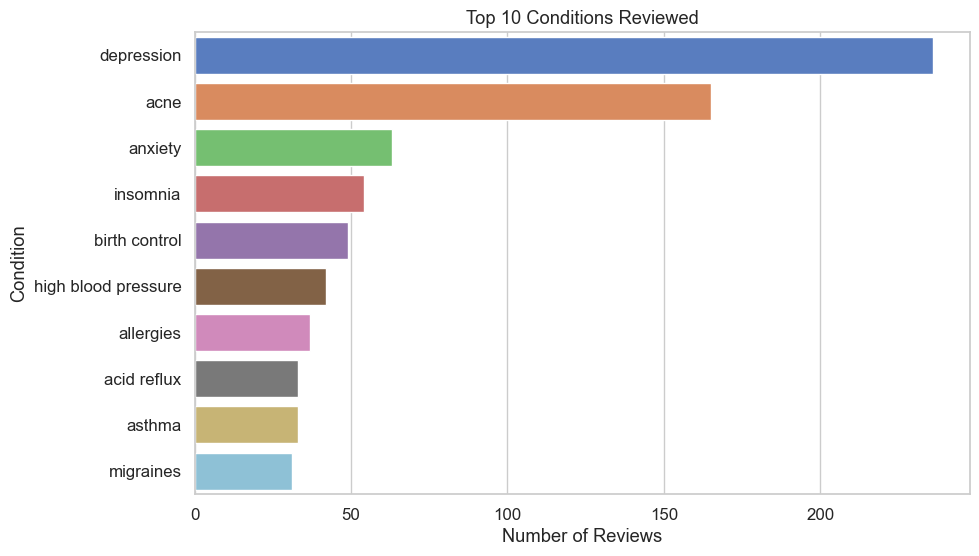

In [2]:
# ==========================================
# 1. Import Libraries
# ==========================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for nicer plots
sns.set(style="whitegrid", palette="muted", font_scale=1.1)


# ==========================================
# 2. Define Correct Column Names (9 total)
# ==========================================
columns = [
    "customer_id",
    "medicine_name",
    "rating",                # 10-star numeric rating
    "effectiveness",         # 5-step categorical
    "side_effects_rating",   # 5-step categorical
    "condition",
    "review_benefits",
    "review_side_effects",
    "review_overall"
]


# ==========================================
# 3. Load Data
# ==========================================
df_train = pd.read_csv("train.tsv", sep="\t", header=None, names=columns)
df_test  = pd.read_csv("test.tsv", sep="\t", header=None, names=columns)

print("Train shape:", df_train.shape)
print("Test shape:", df_test.shape)


# ==========================================
# 4. Sanity Checks
# ==========================================
print("\nPreview of train data:")
print(df_train.head(3))

print("\nMissing values per column:")
print(df_train.isnull().sum())

print("\nBasic statistics for rating:")
print(df_train['rating'].describe())


# ==========================================
# 5. Exploratory Data Analysis (3 Plots)
# ==========================================

# --- Plot 1: Distribution of ratings
plt.figure(figsize=(8,5))
sns.histplot(df_train['rating'], bins=10, kde=False)
plt.title("Distribution of Overall Ratings")
plt.xlabel("Rating (1–10)")
plt.ylabel("Count")
plt.show()


# --- Plot 2: Effectiveness distribution
plt.figure(figsize=(8,5))
sns.countplot(data=df_train, x='effectiveness', order=df_train['effectiveness'].value_counts().index)
plt.title("Effectiveness Ratings Distribution")
plt.xlabel("Effectiveness Category")
plt.ylabel("Count")
plt.show()


# --- Plot 3: Top 10 conditions by number of reviews
plt.figure(figsize=(10,6))
top_conditions = df_train['condition'].value_counts().head(10)
sns.barplot(x=top_conditions.values, y=top_conditions.index)
plt.title("Top 10 Conditions Reviewed")
plt.xlabel("Number of Reviews")
plt.ylabel("Condition")
plt.show()


In [3]:
# ==========================================
# 6. Create Sentiment Labels
# ==========================================

# Apply function to map ratings to sentiment
def label_sentiment(rating):
    if rating >= 7:
        return "positive"
    elif rating <= 4:
        return "negative"
    else:
        return "neutral"   # 5–6

# Create new column 'sentiment'
df_train['sentiment'] = df_train['rating'].apply(label_sentiment)
df_test['sentiment']  = df_test['rating'].apply(label_sentiment)

# Drop neutral reviews
df_train = df_train[df_train['sentiment'] != "neutral"]
df_test  = df_test[df_test['sentiment']  != "neutral"]

print("Train shape after removing neutral:", df_train.shape)
print("Test shape after removing neutral:", df_test.shape)

# Quick check
print(df_train['sentiment'].value_counts())
print(df_train.head())
print(df_test.head())



Train shape after removing neutral: (2791, 10)
Test shape after removing neutral: (911, 10)
positive    2130
negative     661
Name: sentiment, dtype: int64
   customer_id     medicine_name  rating         effectiveness  \
0         2202         enalapril       4      Highly Effective   
1         3117  ortho-tri-cyclen       1      Highly Effective   
2         1146           ponstel      10      Highly Effective   
3         3947          prilosec       3  Marginally Effective   
4         1951           lyric's       2  Marginally Effective   

   side_effects_rating                               condition  \
0    Mild Side Effects  management of congestive heart failure   
1  Severe Side Effects                        birth prevention   
2      No Side Effects                        menstrual cramps   
3    Mild Side Effects                             acid reflux   
4  Severe Side Effects                            fibromyalgia   

                                     review_benefi

In [4]:
# ==========================================
# 7. Combine Text Columns
# ==========================================
df_train['text'] = (
    df_train['review_benefits'].fillna('') + " " +
    df_train['review_side_effects'].fillna('') + " " +
    df_train['review_overall'].fillna('')
)

df_test['text'] = (
    df_test['review_benefits'].fillna('') + " " +
    df_test['review_side_effects'].fillna('') + " " +
    df_test['review_overall'].fillna('')
)

print("\nExample combined review:")
print(df_train['text'].iloc[0])
print(df_train.head(1))


Example combined review:
slowed the progression of left ventricular dysfunction into overt heart failure 
alone or with other agents in the managment of hypertension 
mangagement of congestive heart failur cough, hypotension , proteinuria, impotence , renal failure , angina pectoris , tachycardia , eosinophilic pneumonitis, tastes disturbances , anusease anorecia , weakness fatigue insominca weakness monitor blood pressure , weight and asses for resolution of fluid
   customer_id medicine_name  rating     effectiveness side_effects_rating  \
0         2202     enalapril       4  Highly Effective   Mild Side Effects   

                                condition  \
0  management of congestive heart failure   

                                     review_benefits  \
0  slowed the progression of left ventricular dys...   

                                 review_side_effects  \
0  cough, hypotension , proteinuria, impotence , ...   

                                      review_overall se

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF vectorizer
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)

X_train = vectorizer.fit_transform(df_train['text'])
X_test  = vectorizer.transform(df_test['text'])

y_train = df_train['sentiment']
y_test  = df_test['sentiment']

print("Shape of X_train:", X_train.shape)


Shape of X_train: (2791, 5000)


In [6]:
from sklearn.linear_model import LogisticRegression

# Train Logistic Regression
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

# Predictions
y_pred = clf.predict(X_test)



Classification Report:
              precision    recall  f1-score   support

    negative       0.91      0.24      0.38       241
    positive       0.78      0.99      0.88       670

    accuracy                           0.79       911
   macro avg       0.85      0.62      0.63       911
weighted avg       0.82      0.79      0.74       911

Accuracy: 0.7925356750823271


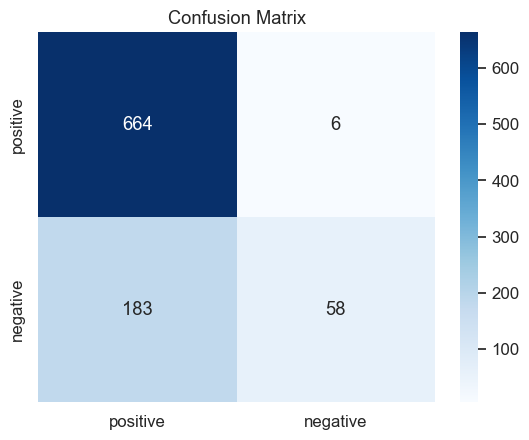

In [7]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=["positive", "negative"])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["positive", "negative"],
            yticklabels=["positive", "negative"])
plt.title("Confusion Matrix")
plt.show()
